In [1]:
!pip install riskfolio-lib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.3/455.3 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found exi

In [12]:
# Install libraries
!pip install riskfolio-lib yfinance --quiet

# Imports
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# NIFTY 10 Stocks
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "INFY.NS",
    "SBIN.NS",
    "LT.NS",
    "BHARTIARTL.NS",
    "ITC.NS",
    "HINDUNILVR.NS"
]

# Download data
prices = yf.download(
    tickers,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

# Remove missing values
prices = prices.dropna()

# Train-Test Split
train = prices.loc[:'2023-01-01']
test = prices.loc['2023-01-02':]

# Daily Returns
train_returns = train.pct_change().dropna()
test_returns = test.pct_change().dropna()

print("Training Shape :", train_returns.shape)
print("Testing Shape  :", test_returns.shape)

train_returns.head()

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4War

Training Shape : (1235, 10)
Testing Shape  : (490, 10)


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2018-01-02,-0.021500,0.009625,-0.004388,-0.001934,-0.003725,-0.005909,-0.008686,0.001539,-0.012537,-0.005443
2018-01-03,0.003194,-0.010521,0.008778,0.017113,-0.008158,0.001534,0.020444,0.004006,-0.001319,0.002832
2018-01-04,0.009263,0.003913,0.001407,-0.000952,-0.005777,0.001532,0.031679,0.006012,0.018656,0.006992
2018-01-05,0.032505,0.001989,0.003180,-0.005720,-0.003349,0.005161,-0.000608,0.003205,-0.006969,0.012080
2018-01-08,-0.043796,-0.001610,0.008736,0.003995,0.023765,0.010270,0.017758,0.005741,-0.001796,0.009371


In [14]:

print(rp.__version__)

7.3.0


In [22]:
!pip install pyportfolioopt --quiet

In [24]:
port = rp.HCPortfolio(returns=train_returns)

w_hrp = port.optimization(
    model="HRP",
    codependence="pearson",
    rm="MV",
    linkage="single",
    leaf_order=True
)

w_hrp = w_hrp.iloc[:,0]

print(w_hrp)

BHARTIARTL.NS    0.059554
HDFCBANK.NS      0.120910
HINDUNILVR.NS    0.168143
ICICIBANK.NS     0.061521
INFY.NS          0.121365
ITC.NS           0.103875
LT.NS            0.089588
RELIANCE.NS      0.067343
SBIN.NS          0.059437
TCS.NS           0.148265
Name: weights, dtype: float64


In [25]:
w_nco = port.optimization(
    model="NCO",
    codependence="pearson",
    obj="Sharpe",
    rm="MV",
    linkage="single",
    leaf_order=True
)

w_nco = w_nco.iloc[:,0]

print(w_nco)

/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 2 times so far.

  warnings.warn(msg, UserWarning)


BHARTIARTL.NS    3.751495e-02
HDFCBANK.NS      1.665719e-09
HINDUNILVR.NS    1.651358e-01
ICICIBANK.NS     1.516474e-01
INFY.NS          2.715450e-01
ITC.NS           1.426944e-02
LT.NS            1.998273e-09
RELIANCE.NS      1.777257e-01
SBIN.NS          2.035756e-09
TCS.NS           1.821616e-01
Name: weights, dtype: float64


/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 3 times so far.

  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 4 times so far.

  warnings.warn(msg, UserWarning)


In [23]:
from pypfopt import EfficientFrontier, expected_returns, risk_models

mu = expected_returns.mean_historical_return(train)
S = risk_models.sample_cov(train)

ef = EfficientFrontier(mu, S)

ef.max_sharpe()

w_mvo = ef.clean_weights()

print(w_mvo)

OrderedDict({'BHARTIARTL.NS': 0.0, 'HDFCBANK.NS': 0.0, 'HINDUNILVR.NS': 0.16027, 'ICICIBANK.NS': 0.13921, 'INFY.NS': 0.33182, 'ITC.NS': 0.0, 'LT.NS': 0.0, 'RELIANCE.NS': 0.17962, 'SBIN.NS': 0.0, 'TCS.NS': 0.18909})


In [27]:
# Convert Markowitz weights to Series
w_mvo = pd.Series(w_mvo)

# Match stock order
w_mvo = w_mvo.reindex(test_returns.columns).fillna(0)

# Portfolio returns
mvo_port = (test_returns * w_mvo).sum(axis=1)

In [28]:
# Match stock order
w_hrp = w_hrp.reindex(test_returns.columns).fillna(0)

# Portfolio returns
hrp_port = (test_returns * w_hrp).sum(axis=1)

In [29]:
# Match stock order
w_nco = w_nco.reindex(test_returns.columns).fillna(0)

# Portfolio returns
nco_port = (test_returns * w_nco).sum(axis=1)

In [30]:
print(mvo_port.head())
print(hrp_port.head())
print(nco_port.head())

Date
2023-01-03    0.000069
2023-01-04   -0.009286
2023-01-05   -0.004955
2023-01-06   -0.011941
2023-01-09    0.022340
dtype: float64
Date
2023-01-03    0.001053
2023-01-04   -0.008983
2023-01-05    0.001564
2023-01-06   -0.008340
2023-01-09    0.018066
dtype: float64
Date
2023-01-03    0.000102
2023-01-04   -0.008651
2023-01-05   -0.004274
2023-01-06   -0.011248
2023-01-09    0.021932
dtype: float64


In [32]:
import numpy as np
import pandas as pd

# Annual Return
def annual_return(r):
    return (1 + r).prod() ** (252 / len(r)) - 1

# Annual Volatility
def annual_volatility(r):
    return r.std() * np.sqrt(252)

# Sharpe Ratio
def sharpe_ratio(r, rf=0):
    return (annual_return(r) - rf) / annual_volatility(r)

# Maximum Drawdown
def max_drawdown(r):
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

# Sortino Ratio
def sortino_ratio(r, rf=0):
    downside = r[r < 0]
    downside_std = downside.std() * np.sqrt(252)
    return (annual_return(r) - rf) / downside_std

# Calmar Ratio
def calmar_ratio(r):
    return annual_return(r) / abs(max_drawdown(r))

In [33]:
results = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown",
        "Calmar Ratio"
    ],
    "Markowitz": [
        annual_return(mvo_port),
        annual_volatility(mvo_port),
        sharpe_ratio(mvo_port),
        sortino_ratio(mvo_port),
        max_drawdown(mvo_port),
        calmar_ratio(mvo_port)
    ],
    "HRP": [
        annual_return(hrp_port),
        annual_volatility(hrp_port),
        sharpe_ratio(hrp_port),
        sortino_ratio(hrp_port),
        max_drawdown(hrp_port),
        calmar_ratio(hrp_port)
    ],
    "NCO": [
        annual_return(nco_port),
        annual_volatility(nco_port),
        sharpe_ratio(nco_port),
        sortino_ratio(nco_port),
        max_drawdown(nco_port),
        calmar_ratio(nco_port)
    ]
})

print(results)

              Metric  Markowitz       HRP       NCO
0      Annual Return   0.114773  0.158294  0.125798
1  Annual Volatility   0.140410  0.115928  0.132678
2       Sharpe Ratio   0.817408  1.365450  0.948148
3      Sortino Ratio   1.298100  2.214988  1.551174
4   Maximum Drawdown  -0.110678 -0.090805 -0.096927
5       Calmar Ratio   1.036998  1.743243  1.297865


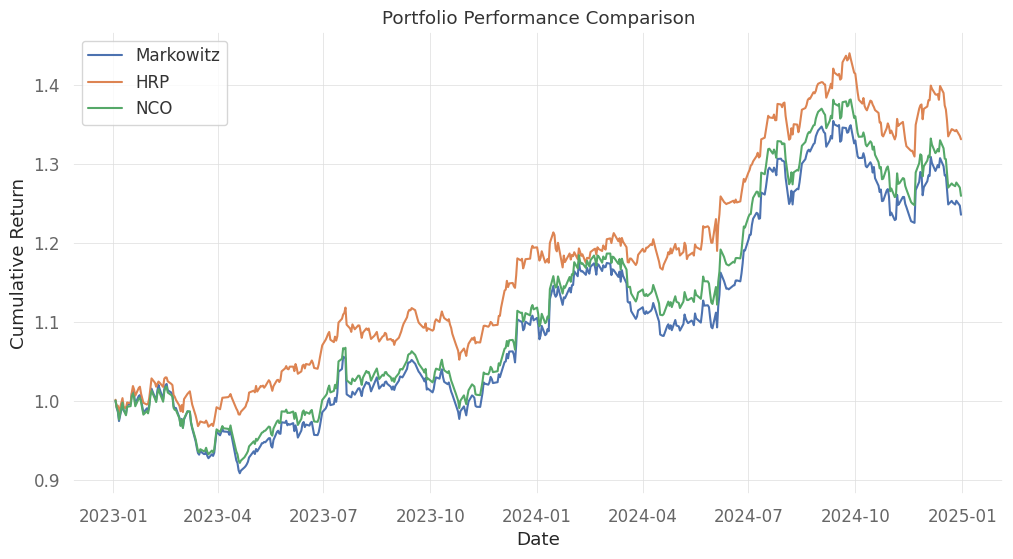

In [34]:
import matplotlib.pyplot as plt

cum_returns = pd.DataFrame({
    "Markowitz": (1 + mvo_port).cumprod(),
    "HRP": (1 + hrp_port).cumprod(),
    "NCO": (1 + nco_port).cumprod()
})

plt.figure(figsize=(12,6))
plt.plot(cum_returns.index, cum_returns["Markowitz"], label="Markowitz")
plt.plot(cum_returns.index, cum_returns["HRP"], label="HRP")
plt.plot(cum_returns.index, cum_returns["NCO"], label="NCO")

plt.title("Portfolio Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from pypfopt import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import risk_models